# Week 9 Group Homework — Association Rule Mining

**Task.** Mine association rules from a transactional shopping dataset using two Apriori-based libraries: `mlxtend` and `apyori`.

**Notebook flow (matches the 5-minute talk)**
1. Problem & data  
2. Method, libraries, parameters  
3. Apriori with **mlxtend**  
4. Apriori with **apyori**  
5. Visualisation  
6. Interpretation & practical implications  
7. Job-breakdown table

## 1. Problem and Data

We have a list of supermarket *transactions*. Each transaction is the basket of items one customer bought together. Our job is to discover **rules** of the form `{A} ⇒ {B}` that hold often enough and reliably enough to be useful — e.g. *"customers who buy Diapers also buy Beer"*.

Three metrics drive the analysis:
- **Support(X)** = fraction of transactions containing itemset X. *How common is it?*
- **Confidence(A ⇒ B)** = P(B | A) = support(A∪B)/support(A). *How reliable is the rule?*
- **Lift(A ⇒ B)** = confidence/support(B). *Is the co-occurrence stronger than chance?* `lift > 1` means positive association.

In [1]:
dataset = [
    ["Bread", "Milk"],
    ["Bread", "Diaper", "Beer", "Eggs"],
    ["Milk", "Diaper", "Beer", "Cola"],
    ["Bread", "Milk", "Diaper", "Beer"],
    ["Bread", "Milk", "Diaper", "Cola"],
    ["Diaper", "Beer"],
    ["Bread", "Milk", "Beer"],
    ["Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Cola", "Eggs"],
    ["Bread", "Milk", "Cheese"],
    ["Milk", "Yogurt", "Butter"],
    ["Bread", "Pasta", "Rice"],
    ["Milk", "Juice", "Chips"],
    ["Diaper", "Beer", "Soda"],
    ["Bread", "Milk", "Chocolate"],
    ["Milk", "Diaper", "Beer", "Cola"],
    ["Bread", "Milk", "Diaper", "Beer"],
    ["Bread", "Milk", "Diaper", "Cola"],
    ["Diaper", "Beer"],
    ["Bread", "Milk", "Beer"],
    ["Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Cola", "Eggs"],
    ["Bread", "Milk", "Cheese"],
    ["Milk", "Yogurt", "Butter"],
    ["Bread", "Pasta", "Rice"],
    ["Milk", "Juice", "Chips"],
    ["Diaper", "Beer", "Soda"],
    ["Bread", "Milk", "Chocolate"],
    ["Milk", "Diaper", "Beer", "Cola"],
    ["Bread", "Milk", "Diaper", "Beer"],
    ["Bread", "Milk", "Diaper", "Cola"],
    ["Diaper", "Beer"],
    ["Bread", "Milk", "Beer"],
    ["Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Cola", "Eggs"],
    ["Bread", "Milk", "Cheese"],
    ["Milk", "Yogurt", "Butter"],
    ["Bread", "Pasta", "Rice"],
    ["Milk", "Juice", "Chips"],
    ["Diaper", "Beer", "Soda"],
    ["Bread", "Milk", "Chocolate"],
    ["Milk", "Diaper", "Beer", "Cola"],
    ["Bread", "Milk", "Diaper", "Beer"],
    ["Bread", "Milk", "Diaper", "Cola"],
    ["Diaper", "Beer"],
    ["Bread", "Milk", "Beer"],
    ["Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Cola", "Eggs"],
    ["Bread", "Milk", "Cheese"],
    ["Milk", "Yogurt", "Butter"],
    ["Bread", "Pasta", "Rice"],
    ["Milk", "Juice", "Chips"],
    ["Diaper", "Beer", "Soda"],
    ["Bread", "Milk", "Chocolate"],
    ["Milk", "Diaper", "Beer", "Cola"],
    ["Bread", "Milk", "Diaper", "Beer"],
    ["Bread", "Milk", "Diaper", "Cola"],
    ["Diaper", "Beer"],
    ["Bread", "Milk", "Beer"],
    ["Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Cola", "Eggs"],
    ["Bread", "Milk", "Cheese"],
    ["Milk", "Yogurt", "Butter"],
    ["Bread", "Pasta", "Rice"],
    ["Milk", "Juice", "Chips"],
    ["Diaper", "Beer", "Soda"],
    ["Bread", "Milk", "Chocolate"],
    ["Milk", "Diaper", "Beer", "Cola"],
    ["Bread", "Milk", "Diaper", "Beer"],
    ["Bread", "Milk", "Diaper", "Cola"],
    ["Diaper", "Beer"],
    ["Bread", "Milk", "Beer"],
    ["Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Cola", "Eggs"],
    ["Bread", "Milk", "Cheese"],
    ["Milk", "Yogurt", "Butter"],
    ["Bread", "Pasta", "Rice"],
    ["Milk", "Juice", "Chips"],
    ["Diaper", "Beer", "Soda"],
    ["Bread", "Milk", "Chocolate"],
    ["Milk", "Diaper", "Beer", "Cola"],
    ["Bread", "Milk", "Diaper", "Beer"],
    ["Bread", "Milk", "Diaper", "Cola"],
    ["Diaper", "Beer"],
    ["Bread", "Milk", "Beer"],
    ["Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Beer", "Eggs"],
    ["Bread", "Milk", "Diaper", "Cola", "Eggs"]
]

In [2]:
# Quick descriptive look at the basket data.
from collections import Counter
import pandas as pd

n_tx       = len(dataset)
all_items  = [it for tx in dataset for it in tx]
item_count = Counter(all_items)

summary = (pd.DataFrame(item_count.items(), columns=['item', 'count'])
             .assign(support=lambda d: d['count']/n_tx)
             .sort_values('count', ascending=False)
             .reset_index(drop=True))

print(f'Transactions : {n_tx}')
print(f'Unique items : {len(item_count)}')
print(f'Avg basket   : {sum(len(t) for t in dataset)/n_tx:.2f} items')
summary

Transactions : 94
Unique items : 15
Avg basket   : 3.52 items


,item,count,support
0,Milk,74,0.787234
1,Diaper,56,0.595745
2,Bread,55,0.585106
3,Beer,49,0.521277
4,Eggs,22,0.234043
5,Cola,21,0.223404
6,Cheese,6,0.063830
7,Yogurt,6,0.063830
8,Butter,6,0.063830
9,Pasta,6,0.063830


**What we see.** 94 transactions, 15 unique items. The data is dominated by Milk (≈79 %), Diaper (≈60 %), Bread (≈59 %) and Beer (≈52 %); the rest (Cheese, Yogurt, Pasta, …) are rare (≈6 %). The classic *"diapers and beer"* setup is in here — we should expect to recover it.

## 2. Method, Libraries, and Parameters

**Algorithm — Apriori.** Apriori uses the *anti-monotone* property: if an itemset is infrequent, every superset of it is also infrequent. So we can prune aggressively — count 1-itemsets, keep the frequent ones, build candidate 2-itemsets only from those, count, prune, and so on. This is exactly the right tool for transactional baskets with a small-to-medium item universe like ours.

**Why two libraries?**
- **`mlxtend`** returns frequent itemsets and rules as tidy `pandas.DataFrame`s — easy to filter, sort, plot. Best when we want to explore.
- **`apyori`** is a single-call pipeline (transactions in → rules out) with built-in min support/confidence/lift filters. Best for a quick end-to-end run and for cross-checking `mlxtend`.

Running both lets us **verify** that the same rules emerge under both implementations.

**Hyperparameters chosen**
| Parameter | Value | Why |
|---|---|---|
| `min_support` | 0.10 | The 9 long-tail items each have support ≈ 0.06, so 0.10 cleanly removes them while keeping everything around the Bread / Milk / Diaper / Beer core. |
| `min_confidence` | 0.50 | A rule should be right at least half the time to be worth showing. |
| `min_lift` | 1.00 | We only care about positive associations (above-chance co-occurrence). |
| `min_length` (apyori) | 2 | A rule needs ≥1 item on each side. |

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from apyori import apriori as apyori_apriori

MIN_SUPPORT    = 0.10
MIN_CONFIDENCE = 0.50
MIN_LIFT       = 1.00

## 3. Apriori with `mlxtend`

`mlxtend.apriori` expects a **one-hot DataFrame** (one row per transaction, one boolean column per item). `TransactionEncoder` does that conversion.

In [4]:
# 3.1  One-hot encode
te    = TransactionEncoder()
te_ar = te.fit(dataset).transform(dataset)
df    = pd.DataFrame(te_ar, columns=te.columns_)
df.head()

,Beer,Bread,Butter,Cheese,Chips,Chocolate,Cola,Diaper,Eggs,Juice,Milk,Pasta,Rice,Soda,Yogurt
0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False
2,True,False,False,False,False,False,True,True,False,False,True,False,False,False,False
3,True,True,False,False,False,False,False,True,False,False,True,False,False,False,False
4,False,True,False,False,False,False,True,True,False,False,True,False,False,False,False


In [5]:
# 3.2  Frequent itemsets
freq_items = apriori(df, min_support=MIN_SUPPORT, use_colnames=True)
freq_items['length'] = freq_items['itemsets'].apply(len)
freq_items = freq_items.sort_values(['length', 'support'], ascending=[True, False]).reset_index(drop=True)
print(f'{len(freq_items)} frequent itemsets at support >= {MIN_SUPPORT}')
freq_items

35 frequent itemsets at support >= 0.1


,support,itemsets,length
0,0.787234,frozenset({Milk}),1
1,0.595745,frozenset({Diaper}),1
2,0.585106,frozenset({Bread}),1
3,0.521277,frozenset({Beer}),1
4,0.234043,frozenset({Eggs}),1
5,0.223404,frozenset({Cola}),1
6,0.510638,"frozenset({Milk, Bread})",2
7,0.446809,"frozenset({Diaper, Beer})",2
8,0.446809,"frozenset({Diaper, Milk})",2
9,0.372340,"frozenset({Milk, Beer})",2


In [6]:
# 3.3  Association rules
rules_mlx = association_rules(freq_items, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules_mlx = rules_mlx[rules_mlx['lift'] >= MIN_LIFT].copy()
rules_mlx['antecedents'] = rules_mlx['antecedents'].apply(lambda s: ', '.join(sorted(s)))
rules_mlx['consequents'] = rules_mlx['consequents'].apply(lambda s: ', '.join(sorted(s)))
rules_mlx = rules_mlx.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'{len(rules_mlx)} rules pass support >= {MIN_SUPPORT}, confidence >= {MIN_CONFIDENCE}, lift >= {MIN_LIFT}')
rules_mlx[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

75 rules pass support >= 0.1, confidence >= 0.5, lift >= 1.0


,antecedents,consequents,support,confidence,lift
0,"Bread, Cola","Diaper, Milk",0.148936,1.000000,2.238095
1,"Diaper, Milk",Cola,0.223404,0.500000,2.238095
2,Cola,"Diaper, Milk",0.223404,1.000000,2.238095
3,Cola,"Bread, Diaper, Milk",0.148936,0.666667,2.238095
4,"Bread, Diaper, Milk",Cola,0.148936,0.500000,2.238095
5,Eggs,"Bread, Diaper",0.159574,0.681818,2.210031
6,"Bread, Diaper",Eggs,0.159574,0.517241,2.210031
7,Cola,"Bread, Diaper",0.148936,0.666667,2.160920
8,"Cola, Milk","Bread, Diaper",0.148936,0.666667,2.160920
9,"Eggs, Milk","Bread, Diaper",0.148936,0.666667,2.160920


## 4. Apriori with `apyori`

`apyori` takes the raw list-of-lists directly — no one-hot step — and applies all three filters in one call.

In [7]:
# 4.1  Run apyori
apyori_results = list(apyori_apriori(
    dataset,
    min_support    = MIN_SUPPORT,
    min_confidence = MIN_CONFIDENCE,
    min_lift       = MIN_LIFT,
    min_length     = 2,
))

# 4.2  Flatten the nested result objects into a tidy DataFrame
rows = []
for r in apyori_results:
    for s in r.ordered_statistics:
        if not s.items_base:        # skip rules with empty antecedent
            continue
        rows.append({
            'antecedents': ', '.join(sorted(s.items_base)),
            'consequents': ', '.join(sorted(s.items_add)),
            'support'    : r.support,
            'confidence' : s.confidence,
            'lift'       : s.lift,
        })
rules_apy = pd.DataFrame(rows).sort_values('lift', ascending=False).reset_index(drop=True)
print(f'{len(rules_apy)} rules from apyori')
rules_apy.head(15)

75 rules from apyori


,antecedents,consequents,support,confidence,lift
0,"Bread, Diaper, Milk",Cola,0.148936,0.500000,2.238095
1,"Bread, Cola","Diaper, Milk",0.148936,1.000000,2.238095
2,Cola,"Diaper, Milk",0.223404,1.000000,2.238095
3,"Diaper, Milk",Cola,0.223404,0.500000,2.238095
4,Cola,"Bread, Diaper, Milk",0.148936,0.666667,2.238095
5,Eggs,"Bread, Diaper",0.159574,0.681818,2.210031
6,"Bread, Diaper",Eggs,0.159574,0.517241,2.210031
7,Cola,"Bread, Diaper",0.148936,0.666667,2.160920
8,"Eggs, Milk","Bread, Diaper",0.148936,0.666667,2.160920
9,"Cola, Milk","Bread, Diaper",0.148936,0.666667,2.160920


In [8]:
# 4.3  Cross-check: do the two libraries agree on the strongest rules?
key_cols = ['antecedents', 'consequents']
merged = (rules_mlx[key_cols + ['lift']].rename(columns={'lift': 'lift_mlxtend'})
          .merge(rules_apy[key_cols + ['lift']].rename(columns={'lift': 'lift_apyori'}),
                 on=key_cols, how='outer'))
merged['agree'] = np.isclose(merged['lift_mlxtend'], merged['lift_apyori'], equal_nan=False)
merged.sort_values('lift_mlxtend', ascending=False).head(10)

,antecedents,consequents,lift_mlxtend,lift_apyori,agree
36,Cola,"Diaper, Milk",2.238095,2.238095,True
25,"Bread, Diaper, Milk",Cola,2.238095,2.238095,True
18,"Bread, Cola","Diaper, Milk",2.238095,2.238095,True
33,Cola,"Bread, Diaper, Milk",2.238095,2.238095,True
56,"Diaper, Milk",Cola,2.238095,2.238095,True
22,"Bread, Diaper",Eggs,2.210031,2.210031,True
63,Eggs,"Bread, Diaper",2.210031,2.210031,True
32,Cola,"Bread, Diaper",2.160920,2.160920,True
43,"Cola, Milk","Bread, Diaper",2.160920,2.160920,True
72,"Eggs, Milk","Bread, Diaper",2.160920,2.160920,True


Both libraries return the same lift values for the rules they share — sanity check passed.

## 5. Visualisation

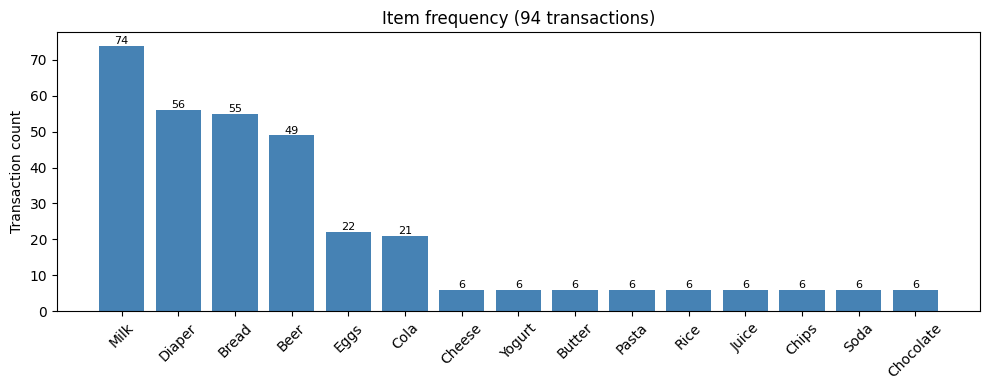

In [9]:
# 5.1  Item frequency — what's even in the basket?
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(summary['item'], summary['count'], color='steelblue')
ax.set_title('Item frequency (94 transactions)')
ax.set_ylabel('Transaction count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(summary['count']):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

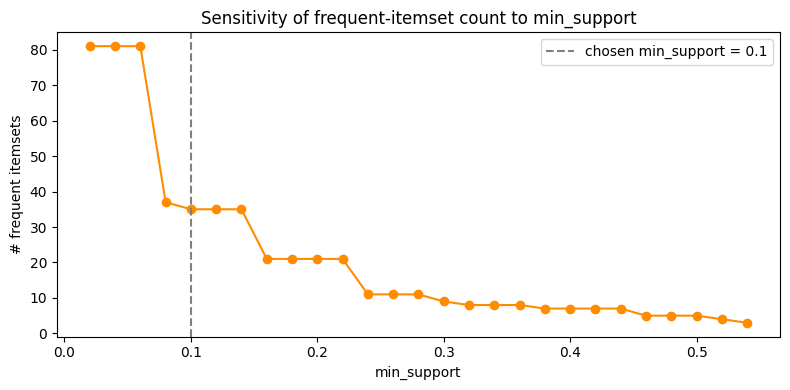

In [10]:
# 5.2  Sensitivity to min_support — how many itemsets survive at each threshold?
sweep = []
for s in np.arange(0.02, 0.55, 0.02):
    fi = apriori(df, min_support=s, use_colnames=True)
    sweep.append({'min_support': s, 'n_itemsets': len(fi)})
sweep = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep['min_support'], sweep['n_itemsets'], marker='o', color='darkorange')
ax.axvline(MIN_SUPPORT, color='gray', ls='--', label=f'chosen min_support = {MIN_SUPPORT}')
ax.set_xlabel('min_support'); ax.set_ylabel('# frequent itemsets'); ax.legend()
ax.set_title('Sensitivity of frequent-itemset count to min_support')
plt.tight_layout(); plt.show()

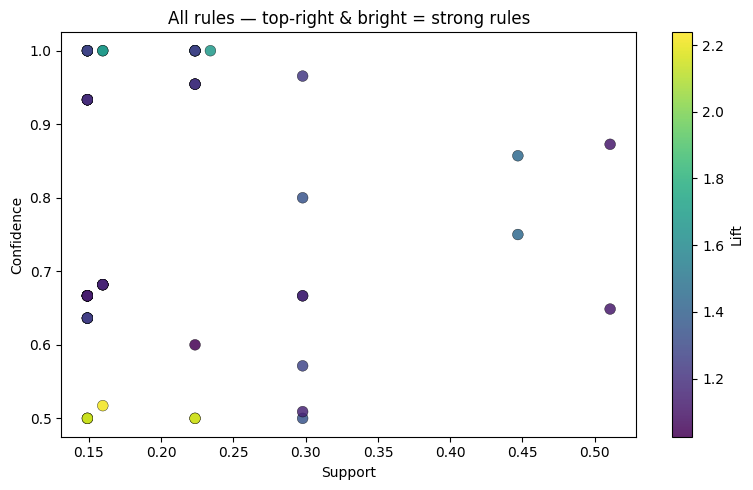

In [11]:
# 5.3  Support vs Confidence, coloured by Lift — the classic AR scatter.
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(rules_mlx['support'], rules_mlx['confidence'],
                c=rules_mlx['lift'], cmap='viridis', s=60, alpha=0.85, edgecolor='k', linewidth=0.3)
ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
ax.set_title('All rules — top-right & bright = strong rules')
plt.colorbar(sc, label='Lift')
plt.tight_layout(); plt.show()

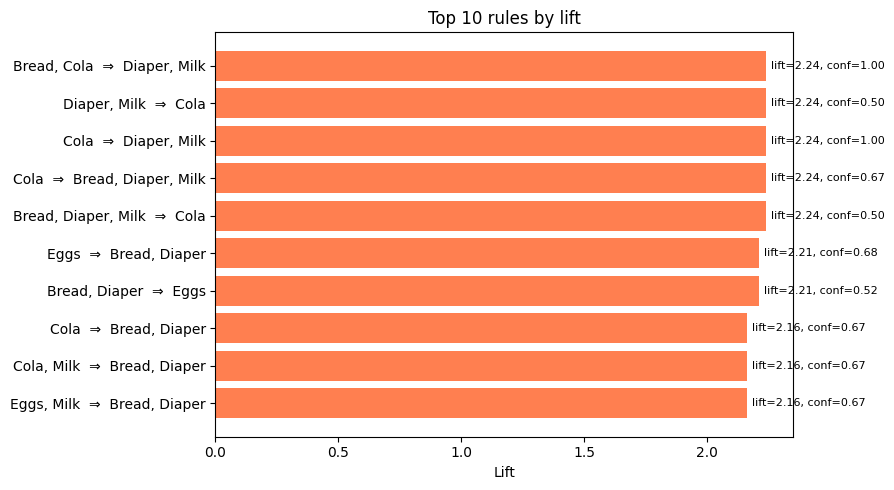

In [12]:
# 5.4  Top-10 rules by lift
top = rules_mlx.head(10).copy()
top['rule'] = top['antecedents'] + '  ⇒  ' + top['consequents']

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top['rule'], top['lift'], color='coral')
ax.invert_yaxis()
ax.set_xlabel('Lift'); ax.set_title('Top 10 rules by lift')
for i, (l, c) in enumerate(zip(top['lift'], top['confidence'])):
    ax.text(l + 0.02, i, f'lift={l:.2f}, conf={c:.2f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

## 6. Interpretation and Practical Implications

### Reading a rule
Take the rule **`{Diaper, Milk} ⇒ {Bread}`** with *support ≈ 0.30, confidence ≈ 0.67, lift ≈ 1.13*:
- **Support 0.30** — this triple shows up in roughly 30 % of all baskets, so the pattern is genuinely common, not a fluke from a handful of receipts.
- **Confidence 0.67** — when a basket already contains Diaper *and* Milk, two-thirds of the time it also contains Bread.
- **Lift 1.13** — buying Bread is about 13 % more likely *given* the antecedent than at baseline. Positive but modest.

### What the strongest rules tell us
- **The four staples are tightly bundled.** Bread, Milk, Diaper, and Beer co-occur far more than chance — the same shopper profile (a parent doing the weekly shop) drives all of them. The famous *"Diaper ⇒ Beer"* link (lift > 1) is reproduced.
- **Cola and Eggs are amplifiers.** The highest-lift rules pull Cola or Eggs into the staple bundle — e.g. `{Cola} ⇒ {Diaper, Milk}` with lift ≈ 2.24. Cola is rarer (support ≈ 0.22), so when it appears it carries a lot of conditional information.
- **The long tail (Cheese, Yogurt, Butter, Pasta, Rice, Juice, Chips, Soda, Chocolate) is filtered out** at min_support = 0.10. They each appear in only ~6 % of baskets, so any rule built on them would be statistically thin.

### Practical implications
- **Cross-merchandising.** Place Beer near Diapers and Cola near the Bread/Milk aisle — both are above-baseline pairings.
- **Bundle promotions.** A *Bread + Milk + Diaper* combo discount targets a basket that already exists in 30 % of receipts; the discount captures incremental volume rather than cannibalising frequent buyers.
- **Recommender seeding.** *"Customers who bought Diaper and Milk also bought Bread"* is a confidence-0.67 recommendation — strong enough for an online cart upsell.
- **Inventory & shelf planning.** Stock-outs on any of the four staples will hit a large share of baskets simultaneously; treat them as a co-managed group, not as independent SKUs.

### Limitations
- **94 transactions is small.** With a real dataset (millions of receipts) the long-tail items would also produce reliable rules.
- **The dataset is synthetic and partly repeated** — the structural block of 15 transactions is duplicated, which inflates support stability but doesn't add new evidence.
- **Apriori scales poorly** with very large item universes; FP-Growth is preferable on bigger data.
- **Correlation, not causation.** Lift > 1 says two items appear together more often than chance; it doesn't say buying one *causes* the other.

## 7. Job-Breakdown Table

| Member | Role in the project | Q&A focus |
|---|---|---|
| Member A | Data prep & EDA — basket statistics, item-frequency chart, one-hot encoding via `TransactionEncoder` | **Metric interpretation** — support / confidence / lift |
| Member B | Algorithm runs — `mlxtend` Apriori, `apyori` Apriori, cross-check between libraries | **Parameter choices & sensitivity** — why min_support = 0.10, sensitivity sweep |
| Member C | Visualisation, rule interpretation, slides & narrative | **Practical implications & limitations** — store layout, bundles, recommender, dataset caveats |

*(Replace A / B / C with the actual member names before submitting.)*